In [1]:
import pandas as pd

df = pd.read_csv(
    'data.csv',
    # nrows=100000
    )
df = df.dropna(subset=['DEP_DELAY'])

display(df)

,Unnamed: 0,FL_DATE,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CRS_ARR_TIME,...,FL_DATE_WEEK,IS_WEEKEND,WEIGHT,ORIGIN_DEGREES,DEST_DEGREES,TOTAL_DELAY_FRM_CATEGORIES,NETT_DELAY,ARR_DELAY_TAG,DEP_DELAY_TAG,DELAY_TAG
0,0,2018-01-01,UA,2429,EWR,DEN,1517,1512.0,-5.0,1745,...,1,False,3130,95,164,0.0,-28.0,False,False,False
1,1,2018-01-01,UA,2427,LAS,SFO,1115,1107.0,-8.0,1254,...,1,False,7883,117,87,0.0,-32.0,False,False,False
2,2,2018-01-01,UA,2426,SNA,DEN,1335,1330.0,-5.0,1649,...,1,False,3593,24,164,0.0,-18.0,False,False,False
3,3,2018-01-01,UA,2425,RSW,ORD,1546,1552.0,6.0,1756,...,1,False,2347,47,175,0.0,4.0,False,False,False
4,4,2018-01-01,UA,2424,ORD,ALB,630,650.0,20.0,922,...,1,False,2011,174,20,0.0,34.0,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7213441,7213441,2018-12-31,AA,1815,DCA,CLT,1534,1530.0,-4.0,1714,...,1,False,3252,90,136,0.0,-9.0,False,False,False
7213442,7213442,2018-12-31,AA,1816,CLT,DFW,1751,1757.0,6.0,1952,...,1,False,3722,136,169,0.0,7.0,False,False,False
7213443,7213443,2018-12-31,AA,1817,CLT,MEM,2015,2010.0,-5.0,2107,...,1,False,2194,136,30,0.0,6.0,True,False,True
7213444,7213444,2018-12-31,AA,1818,CLT,RDU,1300,1323.0,23.0,1350,...,1,False,3173,136,57,0.0,37.0,True,True,True


In [4]:
features = [
            # 'FL_DATE',
              'OP_CARRIER',
            #   'OP_CARRIER_FL_NUM',
              'ORIGIN',
              'DEST',
            #   'CRS_DEP_TIME', # use planned departure time
              # 'DEP_TIME',
            #   'DEP_DELAY',
              # 'CRS_ARR_TIME',
            #   'ARR_TIME',
            #   'ARR_DELAY',
            #   'CANCELLED',
            #   'CANCELLATION_CODE',
            #   'DIVERTED',
            #   'CRS_ELAPSED_TIME',
            #   'ACTUAL_ELAPSED_TIME',
            #   'AIR_TIME',
            #   'DISTANCE',
            #   'CARRIER_DELAY',
            #   'WEATHER_DELAY',
            #   'NAS_DELAY',
            #   'SECURITY_DELAY',
            #   'LATE_AIRCRAFT_DELAY',
            #   'DEP_TIME_MINUTES',
            #   'ARR_TIME_MINUTES',
            #   'ACTUAL_ELAPSED_TIME_MINUTES',
            #   'CRS_DEP_TIME_MINUTES',
            #   'CRS_ARR_TIME_MINUTES',
            #   'CRS_ELAPSED_TIME_MINUTES',
              'FL_DATE_MONTH',
              'FL_DATE_DAY',
              'FL_TIME',
              'FL_DATE_WEEK',
              'IS_WEEKEND',
            #   'WEIGHT',
            #   'ORIGIN_DEGREES',
            #   'DEST_DEGREES',
            #   'TOTAL_DELAY_FRM_CATEGORIES',
            #   'NETT_DELAY',
            #   'ARR_DELAY_TAG',
            #   'DEP_DELAY_TAG',
            #   'DELAY_TAG'
              ]


In [4]:
import sys
!{sys.executable} -m pip install joblib scikit-learn category-encoders xgboost

import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from category_encoders import TargetEncoder

# CUSTOM TRANSFORMER FOR TIME
class TimeCyclicalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, time_col):
        self.time_col = time_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Convert time objects to total minutes from midnight
        # Handles both datetime.time objects and strings
        def get_minutes(t):
            return (t.hour * 60) + t.minute

        minutes = X[self.time_col].apply(get_minutes)
        X['dep_time_sin'] = np.sin(2 * np.pi * minutes / 1440)
        X['dep_time_cos'] = np.cos(2 * np.pi * minutes / 1440)

        # Drop the original time column so the model doesn't see it
        return X.drop(columns=[self.time_col])

df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['FL_TIME'] = df['FL_DATE'].dt.time

# Define features
features = ['FL_DATE_MONTH', 'FL_DATE_DAY', 'IS_WEEKEND', 'FL_TIME', 'ORIGIN', 'DEST', 'OP_CARRIER']
X = df[features]
y = df['DEP_DELAY']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# define pipeline
candidate_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6)
}

results = {}
trained_pipelines = {}

for name, model in candidate_models.items():
    # build pipeline
    pipe = Pipeline([
        ('time_enc', TimeCyclicalEncoder(time_col='FL_TIME')),
        ('target_enc', TargetEncoder(cols=['ORIGIN', 'DEST', 'OP_CARRIER'])),
        ('regressor', model)
    ])

    pipe.fit(X_train, y_train)
    preds = np.maximum(pipe.predict(X_test), 0)

    mae = mean_absolute_error(y_test, preds)
    results[name] = mae
    trained_pipelines[name] = pipe
    print(f"{name} MAE: {mae:.2f}")

# save the best model
best_name = min(results, key=results.get)
joblib.dump(trained_pipelines[best_name], 'final_flight_pipeline.pkl')
print(f"\nSaved the {best_name} pipeline.")

  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
  Using cached category_encoders-2.9.0-py3-none-any.whl (85 kB)
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
  Using cached statsmodels-0.14.6-cp311-cp311-win_amd64.whl (9.6 MB)



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Linear Regression MAE: 20.77
Random Forest MAE: 20.46
XGBoost MAE: 20.40

Saved the XGBoost pipeline.


                                              0.0/554.9 kB ? eta -:--:--
     ----------------------                337.9/554.9 kB 10.6 MB/s eta 0:00:01
     ------------------------------------- 554.9/554.9 kB 11.6 MB/s eta 0:00:00
                                              0.0/8.2 MB ? eta -:--:--
     ----                                     0.8/8.2 MB 26.4 MB/s eta 0:00:01
     ----------                               2.2/8.2 MB 27.7 MB/s eta 0:00:01
     -----------------                        3.7/8.2 MB 29.2 MB/s eta 0:00:01
     --------------------------               5.4/8.2 MB 31.1 MB/s eta 0:00:01
     ----------------------------------       7.1/8.2 MB 32.3 MB/s eta 0:00:01
     ---------------------------------------- 8.2/8.2 MB 30.9 MB/s eta 0:00:00
                                              0.0/2.7 MB ? eta -:--:--
     ------------------------------           2.1/2.7 MB 44.7 MB/s eta 0:00:01
     ---------------------------------------- 2.7/2.7 MB 43.4 MB/s eta 0


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


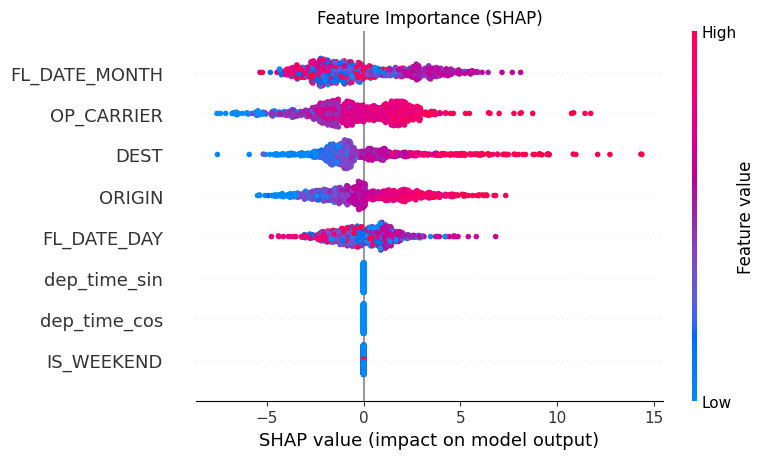

In [6]:
import sys
!{sys.executable} -m pip install shap matplotlib

import shap
import matplotlib.pyplot as plt

best_pipe = trained_pipelines["XGBoost"]
model = best_pipe.named_steps['regressor']

X_test_transformed = best_pipe.named_steps['time_enc'].transform(X_test)
X_test_transformed = best_pipe.named_steps['target_enc'].transform(X_test_transformed)

explainer = shap.Explainer(model)
shap_values = explainer(X_test_transformed.iloc[:1000, :])

plt.title("Feature Importance (SHAP)")
shap.summary_plot(shap_values, X_test_transformed.iloc[:1000, :])


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


                                              0.0/294.9 kB ? eta -:--:--
     -------------------------------------- 294.9/294.9 kB 9.2 MB/s eta 0:00:00


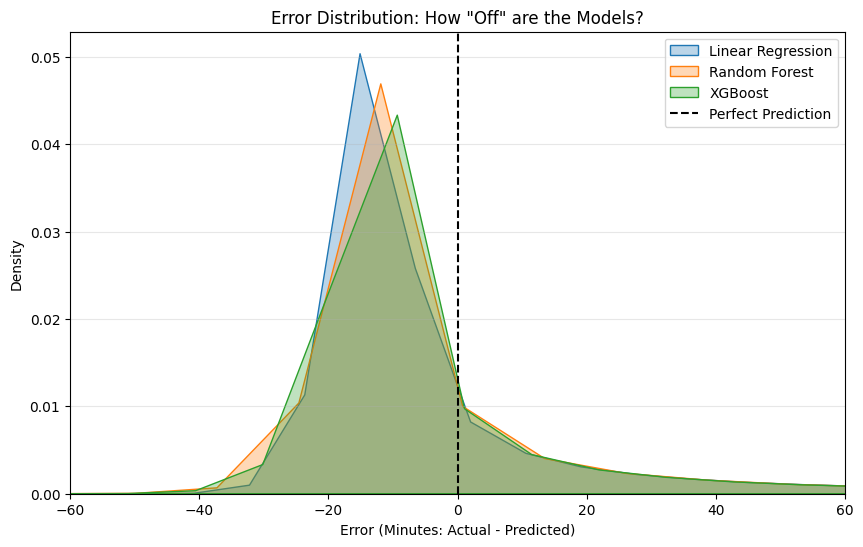

In [7]:
import sys
!{sys.executable} -m pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

for name, pipe in trained_pipelines.items():

    preds = np.maximum(pipe.predict(X_test), 0)

    residuals = y_test - preds

    sns.kdeplot(residuals, label=name, fill=True, common_norm=False, alpha=0.3)

plt.axvline(x=0, color='black', linestyle='--', label='Perfect Prediction')
plt.xlim(-60, 60)
plt.xlabel('Error (Minutes: Actual - Predicted)')
plt.ylabel('Density')
plt.title('Error Distribution: How "Off" are the Models?')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [10]:
# HI KELLY AND PHILIP!!! USE THIS FOR INFERENCE

import joblib
import pandas as pd
import numpy as np
from datetime import time

from sklearn.base import BaseEstimator, TransformerMixin

class TimeCyclicalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, time_col):
        self.time_col = time_col
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        def get_minutes(t):
            # Handles Python time objects
            return (t.hour * 60) + t.minute
        minutes = X[self.time_col].apply(get_minutes)
        X['dep_time_sin'] = np.sin(2 * np.pi * minutes / 1440)
        X['dep_time_cos'] = np.cos(2 * np.pi * minutes / 1440)
        return X.drop(columns=[self.time_col])

# load model
model_pipeline = joblib.load('final_flight_pipeline.pkl')

# Create a new flight example
# Note that it's a list, so can pass multiple flights or just one
new_flight = pd.DataFrame([{
    'FL_DATE_MONTH': 12,
    'FL_DATE_DAY': 2,
    'IS_WEEKEND': 0,
    'FL_TIME': time(14, 30), # 2:30 PM
    'ORIGIN': 'ORD',
    'DEST': 'LGA',
    'OP_CARRIER': 'UA'
}])

# Run prediction
prediction = model_pipeline.predict(new_flight)
final_result = max(0, prediction[0])

print(f"--- Flight Delay Prediction ---")
print(f"Predicted Departure Delay: {final_result:.1f} minutes")

--- Flight Delay Prediction ---
Predicted Departure Delay: 7.6 minutes
